### **Smart Traffic Density Analyzer**

**Phase 1: Data Preprocessing**

Objectives

Load traffic sign images

Resize images

Normalize pixel values

Visualize classes

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
path = kagglehub.dataset_download(
    "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset Path: /kaggle/input/gtsrb-german-traffic-sign


In [3]:
train_csv = os.path.join(path, "Train.csv")
df = pd.read_csv(train_csv)
df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
print(df.shape)

(39209, 8)


In [6]:
df.columns

Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')

In [7]:
print(df["ClassId"].value_counts())

ClassId
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
35    1200
18    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
6      420
16     420
34     420
22     390
36     390
20     360
40     360
21     330
39     300
29     270
24     270
42     240
32     240
27     240
41     240
0      210
19     210
37     210
Name: count, dtype: int64


In [8]:
IMG_SIZE = 32

images = []
labels = []

for i in range(len(df)):
    img_path = os.path.join(path, df.iloc[i]["Path"])
    image = cv2.imread(img_path)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    images.append(image)
    labels.append(df.iloc[i]["ClassId"])

X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(39209, 32, 32, 3)
(39209,)


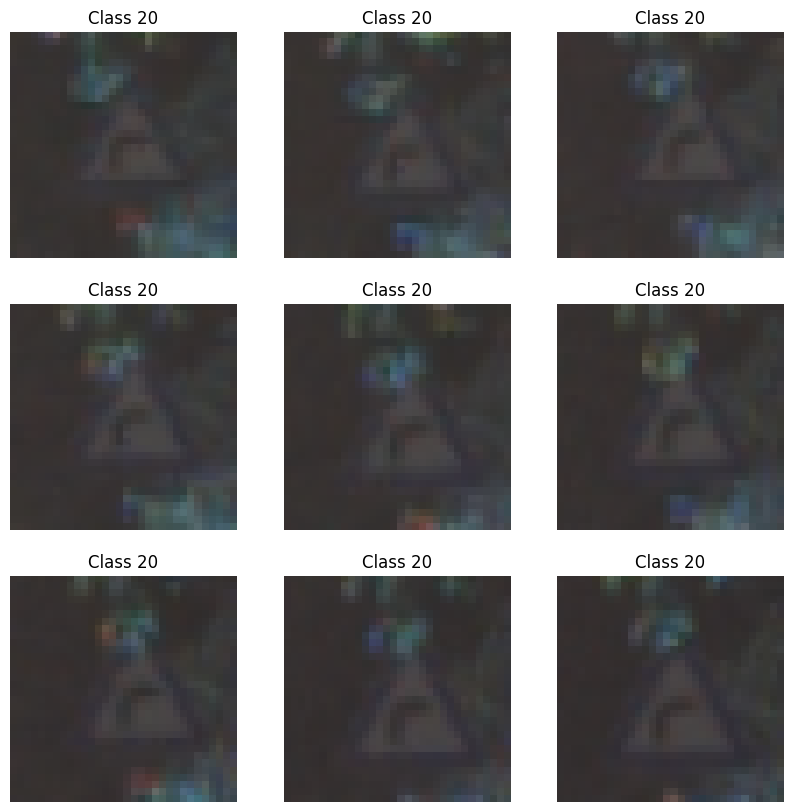

In [11]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(f"Class {y[i]}")
    plt.axis("off")
plt.show()

**Phase 2: Build CNN Model**

Detect:

Stop Sign

Speed Limit

No Entry

In [12]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(y)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [15]:
model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)
model.add(MaxPooling2D((2,2)))
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D((2,2)))
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.4181 - loss: 2.0575 - val_accuracy: 0.8393 - val_loss: 0.6490
Epoch 2/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8295 - loss: 0.5554 - val_accuracy: 0.9458 - val_loss: 0.1885
Epoch 3/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9170 - loss: 0.2755 - val_accuracy: 0.9743 - val_loss: 0.1002
Epoch 4/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.9476 - loss: 0.1702 - val_accuracy: 0.9810 - val_loss: 0.0641
Epoch 5/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9609 - loss: 0.1307 - val_accuracy: 0.9849 - val_loss: 0.0533
Epoch 6/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.9673 - loss: 0.1028 - val_accuracy: 0.9888 - val_loss: 0.0458
Epoch 7/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.9749 - loss: 0.0799 - val_accuracy: 0.9904 - val_loss: 0.0385
Epoch 8/10
785/785 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.9784 - loss: 0.0658 - 

In [18]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("Accuracy:", accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9887 - loss: 0.0403
Accuracy: 0.9886508584022522


In [19]:
model.save("traffic_sign_cnn_model.h5")

In [20]:
from tensorflow.keras.models import load_model

model = load_model(
    "traffic_sign_cnn_model.h5"
)

In [23]:
sample_path = os.path.join(path, df.iloc[100]["Path"])
image = cv2.imread(sample_path)
cv2.imwrite("test.jpg", image)

True

In [24]:
from google.colab import files
files.download("test.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
image = cv2.imread("test.jpg")
image = cv2.resize(
    image,
    (32,32)
)
image = image / 255.0
image = np.expand_dims(
    image,
    axis=0
)
prediction = model.predict(image)
class_id = np.argmax(prediction)
print("Predicted Class:", class_id)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted Class: 20


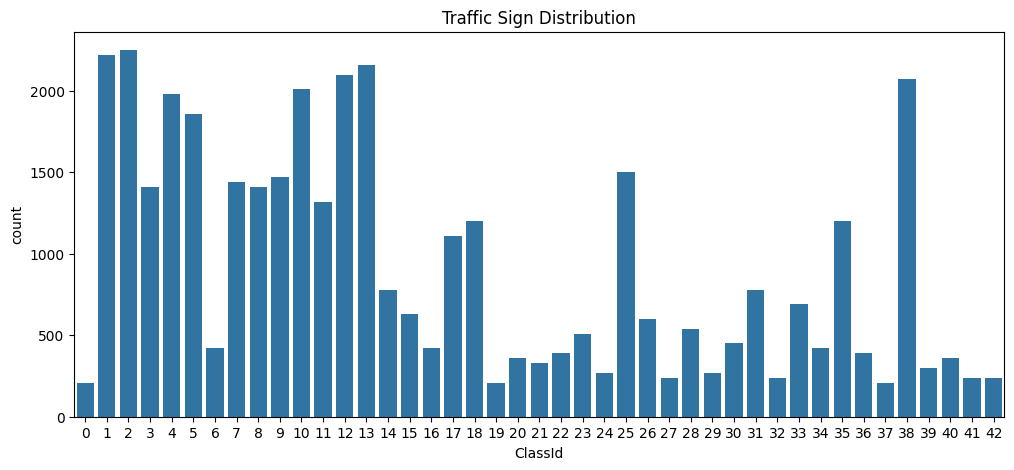

In [26]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(x=df["ClassId"])
plt.title("Traffic Sign Distribution")
plt.show()

In [27]:
pred_classes = np.argmax(
    model.predict(X_test),
    axis=1
)
pd.Series(
    pred_classes
).value_counts().head(10)

246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


,count
1,466
2,465
12,454
13,441
38,420
4,419
10,349
5,329
9,306
25,291


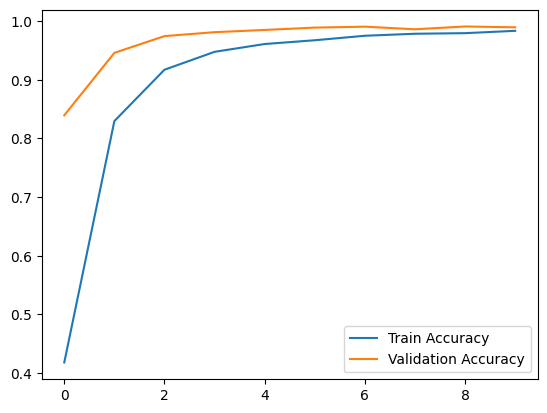

In [28]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

In [29]:
from google.colab import files

files.download("traffic_sign_cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

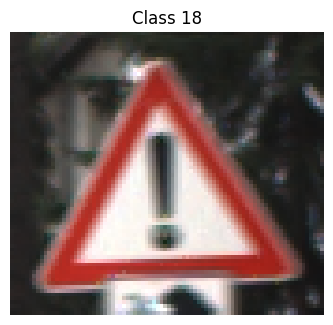

In [36]:
import random

plt.figure(figsize=(10,10))

for i in range(1):
    idx = random.randint(0, len(df)-1)

    img_path = os.path.join(path, df.iloc[idx]["Path"])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Class {df.iloc[idx]['ClassId']}")
    plt.axis("off")

plt.tight_layout()
plt.show()